In [41]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_community.llms import Ollama

In [2]:
# Specify the file path
file_path = "inflação/data/human/human_conciliado_220.csv"

# Load the dataset
df = pd.read_csv(
    file_path,
    sep='|', 
    parse_dates=['Date'],  # Converte a coluna Date para o tipo datetime
    dayfirst=True,          # Interpreta datas no formato DD/MM/YYYY
    encoding='utf-8'
)

# Display the first few rows of the dataset
print(df.head())

        Date  Model  Grade                                           Sentence
0 2009-09-02  human     -1  No médio prazo, o risco advém dos efeitos, cum...
1 2011-11-30  human     -1  Os preços livres aumentaram 7, 24% no período ...
2 2009-10-21  human      0  Nesse contexto, após um período de flexibiliza...
3 2013-04-17  human     -1  Considerada a série observada, o Nuci apresent...
4 2002-11-20  human     -1  Dados preliminares da Fecomércio mostram que o...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      220 non-null    datetime64[ns]
 1   Model     220 non-null    object        
 2   Grade     220 non-null    int64         
 3   Sentence  220 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 7.0+ KB


In [4]:
inicio = time.time()
llm = Ollama(model="gemma4:e4b", temperature=0)  # ajuste modelo/parametros conforme necessário
prompt = "Olá modelo como estás?"
resp_text = llm.invoke(prompt)
fim = time.time()
duracao = fim - inicio
print(f'duracao: {duracao}\n{resp_text}\n\n')

/tmp/ipykernel_3333561/1081730878.py:2: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="gemma4:e4b", temperature=0)  # ajuste modelo/parametros conforme necessário


duracao: 5.908091306686401
Olá! Estou bem, obrigado/a por perguntar. 😊

Como posso ajudar você hoje? E você, como está?




In [27]:
MODEL = "gemma4:e4b"

PROMPT = """
DEFINIÇÃO DE OTIMISMO:
Ocorre quando as projeções indicam que a inflação ficará abaixo da meta ou dentro do intervalo de tolerância com folga. 
Isso pode sinalizar que o Banco Central vê espaço para reduzir juros ou manter uma política monetária mais acomodatícia. 

DEFINIÇÃO DE PESSIMISMO:
Ocorre quando as projeções apontam para inflação acima da meta ou próxima do teto do intervalo de tolerância. 
Isso sugere preocupação com pressões inflacionárias e pode justificar uma política monetária mais restritiva.

AVALIE A FRASE COMO
O para OTIMISTA
N para NEUTRA
P para PESSIMISTA
SUA RESPOSTA DEVE SER APENAS UMA DAS 3 LETRAS, SEM QUALQUER OUTRO TEXTO

A FRASE É:
"""

GRADE_MAP = {'O': 1, 'N': 0, 'P': -1}
REVERSE_GRADE_MAP = {1: 'O', 0: 'N', -1: 'P'}


In [28]:
pred2num = {'O': 1, 'N': 0, 'P': -1}

In [29]:
def build_few_shot_messages(existing, actual):
    messages = []
    seen_sentences = set()
    for idx, r in df.iterrows():
        sentence = r['Sentence']
        if sentence == actual:
            continue
        if r['Model'] == 'human' and sentence not in seen_sentences:
            seen_sentences.add(sentence)
            letter = REVERSE_GRADE_MAP[r['Grade']]
            messages.append(HumanMessage(content=PROMPT + sentence))
            messages.append(AIMessage(content=letter))
    return messages


In [30]:

few_shot_messages = build_few_shot_messages(df, None)
len(few_shot_messages)//2

216

In [31]:
few_shot_messages

[HumanMessage(content='\nDEFINIÇÃO DE OTIMISMO:\nOcorre quando as projeções indicam que a inflação ficará abaixo da meta ou dentro do intervalo de tolerância com folga. \nIsso pode sinalizar que o Banco Central vê espaço para reduzir juros ou manter uma política monetária mais acomodatícia. \n\nDEFINIÇÃO DE PESSIMISMO:\nOcorre quando as projeções apontam para inflação acima da meta ou próxima do teto do intervalo de tolerância. \nIsso sugere preocupação com pressões inflacionárias e pode justificar uma política monetária mais restritiva.\n\nAVALIE A FRASE COMO\nO para OTIMISTA\nN para NEUTRA\nP para PESSIMISTA\nSUA RESPOSTA DEVE SER APENAS UMA DAS 3 LETRAS, SEM QUALQUER OUTRO TEXTO\n\nA FRASE É:\nNo médio prazo, o risco advém dos efeitos, cumulativos e defasados, da distensão das condições financeiras e do impulso fiscal sobre a evolução da demanda doméstica, levando-se em conta a dinâmica do consumo e do investimento, em contexto de retomada da utilização dos fatores de produção.', ad

In [33]:
if not 'Prediction' in df.columns:
    df['Prediction'] = None

for idx, r in df.iterrows():
    if r['Prediction'] in [0, 1, -1]: continue
    sentence = r['Sentence']
    print(idx, end=' ')
    few_shot_messages = build_few_shot_messages(df, r['Sentence'])
    print(len(few_shot_messages)//2, end=' ')
    messages = few_shot_messages + [HumanMessage(content=PROMPT + sentence)]
    #break
    resp_text = llm.invoke(messages)
    resp_text = resp_text.strip('AI: ')
    print(resp_text)
    #r['Prediction'] = resp_text
    df.loc[idx, 'Prediction'] = pred2num[resp_text]
    #break

3 215 N
4 215 N
5 215 P
6 215 N
7 215 P
8 215 N
9 215 O
10 215 N
11 215 N
12 215 O
13 215 O
14 215 N
15 215 P
16 215 O
17 215 N
18 215 N
19 215 N
20 215 P
21 215 N
22 215 N
23 215 N
24 215 P
25 215 N
26 215 O
27 215 N
28 215 O
29 215 N
30 215 O
31 215 N
32 215 N
33 215 P
34 215 N
35 215 N
36 215 N
37 215 N
38 215 O
39 215 O
40 215 P
41 215 O
42 215 O
43 215 O
44 215 N
45 215 P
46 215 N
47 215 O
48 215 O
49 215 N
50 215 N
51 215 O
52 215 N
53 215 P
54 215 N
55 215 N
56 215 P
57 215 P
58 215 P
59 215 N
60 215 O
61 215 N
62 215 O
63 215 N
64 215 P
65 215 O
66 215 N
67 215 N
68 215 P
69 215 N
70 215 N
71 215 O
72 215 P
73 215 O
74 215 N
75 215 P
76 215 N
77 215 N
78 215 N
79 215 N
80 215 P
81 215 N
82 215 N
83 215 N
84 215 N
85 215 N
86 215 N
87 215 O
88 215 O
89 215 P
90 215 N
91 215 N
92 215 P
93 215 N
94 215 N
95 215 N
96 215 P
97 215 O
98 215 P
99 215 O
100 215 N
101 215 N
102 215 P
103 215 N
104 215 N
105 215 O
106 215 P
107 215 N
108 215 O
109 215 O
110 215 N
111 215 O
112 215 P
113 

In [34]:
df.head()

,Date,Model,Grade,Sentence,Prediction
0,2009-09-02,human,-1,"No médio prazo, o risco advém dos efeitos, cum...",-1
1,2011-11-30,human,-1,"Os preços livres aumentaram 7, 24% no período ...",0
2,2009-10-21,human,0,"Nesse contexto, após um período de flexibiliza...",0
3,2013-04-17,human,-1,"Considerada a série observada, o Nuci apresent...",0
4,2002-11-20,human,-1,Dados preliminares da Fecomércio mostram que o...,0


In [35]:
df.tail()

,Date,Model,Grade,Sentence,Prediction
215,2019-10-30,human,0,As estimativas e projeções de curto prazo indi...,0
216,2004-07-21,human,-1,O núcleo de inflação para o IPCA calculado por...,0
217,2008-12-10,human,-1,"Em síntese, ainda não se consolidou o processo...",0
218,2019-03-20,human,0,Todos os membros do Comitê voltaram a enfatiza...,1
219,2010-03-17,human,0,No período posterior à reunião do Copom de jan...,0


In [36]:
df.rename(columns={'Prediction': 'many_shot-gemma4:e4b'}, inplace=True)
df.head()

,Date,Model,Grade,Sentence,many_shot-gemma4:e4b
0,2009-09-02,human,-1,"No médio prazo, o risco advém dos efeitos, cum...",-1
1,2011-11-30,human,-1,"Os preços livres aumentaram 7, 24% no período ...",0
2,2009-10-21,human,0,"Nesse contexto, após um período de flexibiliza...",0
3,2013-04-17,human,-1,"Considerada a série observada, o Nuci apresent...",0
4,2002-11-20,human,-1,Dados preliminares da Fecomércio mostram que o...,0


In [38]:
from sklearn.metrics import classification_report

# Remove valores nulos caso haja linhas não processadas
df_clean = df.dropna(subset=['Grade', 'many_shot-gemma4:e4b'])

# Garante que as colunas estejam no mesmo formato de texto
y_true = df_clean['Grade'].astype(str)
y_pred = df_clean['many_shot-gemma4:e4b'].astype(str)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

          -1       0.77      0.59      0.67        61
           0       0.71      0.79      0.75       111
           1       0.61      0.62      0.62        48

    accuracy                           0.70       220
   macro avg       0.70      0.67      0.68       220
weighted avg       0.70      0.70      0.70       220



In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

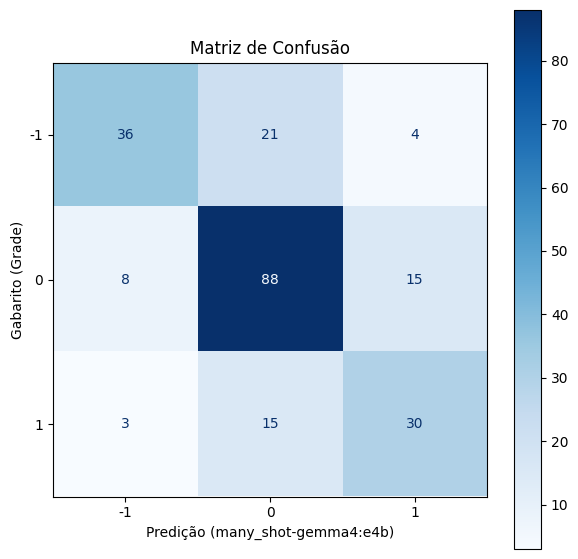

In [42]:
# Plota a matriz diretamente com Matplotlib
fig, ax = plt.subplots(figsize=(7, 7))

ConfusionMatrixDisplay.from_predictions(
    y_true, 
    y_pred, 
    cmap=plt.cm.Blues, 
    ax=ax,
    colorbar=True
)

plt.title('Matriz de Confusão')
plt.xlabel('Predição (many_shot-gemma4:e4b)')
plt.ylabel('Gabarito (Grade)')
plt.show()